# Эксперименты с глубоким обучением (CNN) для классификации дефектов речи

In [ ]:
import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
import torchaudio.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gdown
import zipfile
import pandas as pd
import warnings
import os
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

In [27]:
TARGET_SR = 16000
MAX_LEN = 10 * TARGET_SR
N_MELS = 128
HOP_LENGTH = 512
N_FFT = 1024
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Загрузка датасета

In [3]:
FILE_ID = "12XMzJ1xRFXAzX8oZ_XwcF-0j9J74ZXNB"
ZIP_PATH = "dataset.zip"
EXTRACT_PATH = "data"
try:
    gdown.download(
        id=FILE_ID,
        output=ZIP_PATH,
        quiet=False,
        fuzzy=True
    )
    print("Загрузка архива завершена!")
except Exception as e:
    print(f"Ошибка при загрузке: {e}")

Downloading...
From (original): https://drive.google.com/uc?id=12XMzJ1xRFXAzX8oZ_XwcF-0j9J74ZXNB
From (redirected): https://drive.google.com/uc?id=12XMzJ1xRFXAzX8oZ_XwcF-0j9J74ZXNB&confirm=t&uuid=5e4b869f-9784-49c7-9c1f-0a9e4a6c2211
To: /content/dataset.zip
100%|██████████| 695M/695M [00:08<00:00, 83.1MB/s]

Загрузка архива завершена!


In [28]:
if os.path.exists(ZIP_PATH):
    print("Распаковка архива")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(EXTRACT_PATH)

Распаковка архива


In [29]:
good_dir = "data/хорошо"
bad_dir = "data/плохо"

In [30]:
file_data = []
for label, folder in [(0, good_dir), (1, bad_dir)]:
    for fname in os.listdir(folder):
        if fname.endswith('.wav'):
            path = os.path.join(folder, fname)
            twister = fname.split('__')[1].replace('.wav', '')
            file_data.append([path, label, fname, twister])

df = pd.DataFrame(file_data, columns=['path', 'label', 'filename', 'twister'])

## Получение спектрограмм

In [31]:
def get_mel_spectrogram(file_path, target_sr=TARGET_SR, n_mels=N_MELS, hop_length=HOP_LENGTH, n_fft=N_FFT, max_len=MAX_LEN):
    y, sr = torchaudio.load(file_path)
    if sr != target_sr:
        resampler = T.Resample(sr, target_sr)
        y = resampler(y)
    if y.shape[0] > 1:
        y = torch.mean(y, dim=0, keepdim=True)
    y = y[0]
    if len(y) > max_len:
        start = (len(y) - max_len) // 2
        y = y[start:start+max_len]
    else:
        pad_len = max_len - len(y)
        y = torch.nn.functional.pad(y, (pad_len//2, pad_len - pad_len//2), mode='constant')

    mel_spec = T.MelSpectrogram(sample_rate=target_sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)(y)
    log_mel = T.AmplitudeToDB()(mel_spec)
    return log_mel

In [17]:
sample_path = df['path'].iloc[0]
spec = get_mel_spectrogram(sample_path)
spec.shape

torch.Size([128, 313])

In [32]:
class MelSpectrogramDataset(Dataset):
    def __init__(self, df, max_time_frames=300):
        self.df = df.reset_index(drop=True)
        self.max_time_frames = max_time_frames

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        spec = get_mel_spectrogram(row['path'])
        if spec.shape[1] > self.max_time_frames:
            start = (spec.shape[1] - self.max_time_frames) // 2
            spec = spec[:, start:start+self.max_time_frames]
        else:
            pad_len = self.max_time_frames - spec.shape[1]
            spec = torch.nn.functional.pad(spec, (pad_len//2, pad_len - pad_len//2), mode='constant')

        spec = spec.unsqueeze(0)
        label = torch.tensor(row['label'], dtype=torch.long)
        return spec, label

In [33]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE, stratify=df['label'])
df_train, df_val = train_test_split(df_train, test_size=0.2, random_state=RANDOM_STATE, stratify=df_train['label'])

In [34]:
train_dataset = MelSpectrogramDataset(df_train)
val_dataset = MelSpectrogramDataset(df_val)
test_dataset = MelSpectrogramDataset(df_test)

In [35]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

## Построение  CNN - модели

In [57]:
class AudioCNN(nn.Module):
    def __init__(self, n_mels=128, time_frames=300, num_classes=2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )
        self.avgpool = nn.AdaptiveAvgPool2d((4,4))
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(32 * 4 * 4, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [71]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [72]:
model_v1 = AudioCNN().to(device)

In [73]:
def train_model(model, train_loader, val_loader, criterion, optimizer, n_epochs=10, device='cuda'):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for imgs, labels in tqdm(train_loader, desc=f'Train Epoch {epoch+1}'):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for imgs, labels in tqdm(val_loader, desc=f'Val Epoch {epoch+1}'):
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * imgs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: \
        \n Train Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f} \
        \n Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    return train_losses, val_losses, train_accs, val_accs

In [74]:
weight_1 = len(df_train[df_train['label']==0]) / len(df_train[df_train['label']==1])
class_weights = torch.tensor([1, weight_1]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model_v1.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

Val Epoch 1: 100%|██████████| 14/14 [00:08<00:00,  1.60it/s]


Epoch 1:         
 Train Loss: 0.6605, Acc: 0.6144         
 Val Loss: 0.6206, Acc: 0.6622


Val Epoch 2: 100%|██████████| 14/14 [00:05<00:00,  2.55it/s]


Epoch 2:         
 Train Loss: 0.6317, Acc: 0.6466         
 Val Loss: 0.6073, Acc: 0.6509


Val Epoch 3: 100%|██████████| 14/14 [00:05<00:00,  2.53it/s]


...

Epoch 28:         
 Train Loss: 0.5853, Acc: 0.6815         
 Val Loss: 0.5889, Acc: 0.6847


Val Epoch 29: 100%|██████████| 14/14 [00:06<00:00,  2.17it/s]


Epoch 29:         
 Train Loss: 0.5893, Acc: 0.6855         
 Val Loss: 0.5879, Acc: 0.6802


Val Epoch 30: 100%|██████████| 14/14 [00:06<00:00,  2.08it/s]


Epoch 30:         
 Train Loss: 0.5885, Acc: 0.6798         
 Val Loss: 0.5907, Acc: 0.6937


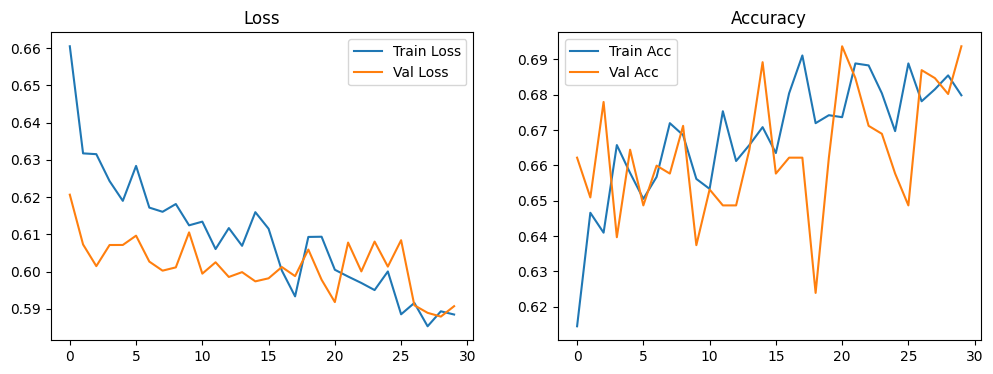

In [75]:
train_losses, val_losses, train_accs, val_accs = train_model(
    model_v1, train_loader, val_loader, criterion, optimizer, n_epochs=30, device=device
)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [76]:
def evaluate_model(model, test_loader, device='cuda'):
    model.eval()
    y_true = []
    y_pred = []
    y_proba = []
    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc='Testing'):
            imgs = imgs.to(device)
            outputs = model(imgs)
            proba = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            y_true.extend(labels.numpy())
            y_pred.extend(preds)
            y_proba.extend(proba)
    print('\n', classification_report(y_true, y_pred, target_names=['Хорошо', 'Плохо']))
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"F1 (плохо): {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_true, y_proba):.4f}")
    return y_true, y_pred, y_proba

y_true, y_pred, y_proba = evaluate_model(model_v1, test_loader, device)

Testing: 100%|██████████| 18/18 [00:08<00:00,  2.24it/s]


               precision    recall  f1-score   support

      Хорошо       0.84      0.74      0.79       375
       Плохо       0.57      0.72      0.63       180

    accuracy                           0.73       555
   macro avg       0.70      0.73      0.71       555
weighted avg       0.75      0.73      0.74       555

Accuracy: 0.7297
F1 (плохо): 0.6324
ROC-AUC: 0.7789


Модель показала значение метрики f1 незначительно больше, чем у лучшей ML-модели(0.632 против 0.629). Но другие значения метрик уступают (Accuracy - 0.73 против 0.74, ROC-AUC - 0.78 против 0.79).

## Попытка улучшения метрик с помощью увеличения весов нечастого класса

Поднимем коэффициент весов до 2.5 для класса "плохо"

In [77]:
model_v2 = AudioCNN().to(device)

In [78]:
class_weights = torch.tensor([1.0, 2.5]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model_v2.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

Val Epoch 1: 100%|██████████| 14/14 [00:06<00:00,  2.06it/s]


Epoch 1:         
 Train Loss: 0.6561, Acc: 0.5846         
 Val Loss: 0.6095, Acc: 0.6577


Val Epoch 2: 100%|██████████| 14/14 [00:05<00:00,  2.56it/s]


Epoch 2:         
 Train Loss: 0.6340, Acc: 0.6201         
 Val Loss: 0.6217, Acc: 0.5856


Val Epoch 3: 100%|██████████| 14/14 [00:05<00:00,  2.49it/s]


...

Epoch 28:         
 Train Loss: 0.5713, Acc: 0.6640         
 Val Loss: 0.5951, Acc: 0.6419


Val Epoch 29: 100%|██████████| 14/14 [00:05<00:00,  2.48it/s]


Epoch 29:         
 Train Loss: 0.5886, Acc: 0.6432         
 Val Loss: 0.5905, Acc: 0.6329


Val Epoch 30: 100%|██████████| 14/14 [00:06<00:00,  2.03it/s]


Epoch 30:         
 Train Loss: 0.5806, Acc: 0.6421         
 Val Loss: 0.5891, Acc: 0.6284


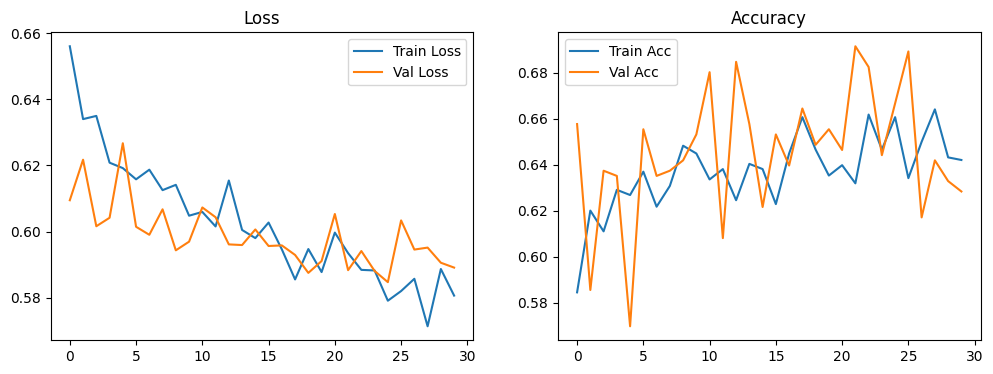

In [79]:
train_losses, val_losses, train_accs, val_accs = train_model(
    model_v2, train_loader, val_loader, criterion, optimizer, n_epochs=30, device=device
)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [80]:
y_true, y_pred, y_proba = evaluate_model(model_v2, test_loader, device)

Testing: 100%|██████████| 18/18 [00:07<00:00,  2.47it/s]


               precision    recall  f1-score   support

      Хорошо       0.86      0.49      0.62       375
       Плохо       0.44      0.83      0.57       180

    accuracy                           0.60       555
   macro avg       0.65      0.66      0.60       555
weighted avg       0.72      0.60      0.61       555

Accuracy: 0.5982
F1 (плохо): 0.5736
ROC-AUC: 0.7732


Значения метрик упали

## Эксперимент с более упрощенной моделью

In [47]:
class AudioCNNv3(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.BatchNorm2d(8), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((4,4))
        self.classifier = nn.Sequential(
            nn.Dropout(0.7),
            nn.Linear(32*4*4, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 2)
        )
    def forward(self, x):
        x = self.conv(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

In [48]:
model_v3 = AudioCNNv3().to(device)

In [49]:
class_weights = torch.tensor([1.0, 2.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model_v3.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

Val Epoch 1: 100%|██████████| 14/14 [00:08<00:00,  1.67it/s]


Epoch 1:         
 Train Loss: 0.6576, Acc: 0.6105         
 Val Loss: 0.6045, Acc: 0.6779


Val Epoch 2: 100%|██████████| 14/14 [00:05<00:00,  2.41it/s]


Epoch 2:         
 Train Loss: 0.6337, Acc: 0.6511         
 Val Loss: 0.6027, Acc: 0.6937


Val Epoch 3: 100%|██████████| 14/14 [00:08<00:00,  1.64it/s]


...

Epoch 28:         
 Train Loss: 0.6019, Acc: 0.6793         
 Val Loss: 0.5923, Acc: 0.7162


Val Epoch 29: 100%|██████████| 14/14 [00:07<00:00,  1.88it/s]


Epoch 29:         
 Train Loss: 0.6166, Acc: 0.6742         
 Val Loss: 0.6034, Acc: 0.6779


Val Epoch 30: 100%|██████████| 14/14 [00:06<00:00,  2.08it/s]


Epoch 30:         
 Train Loss: 0.6094, Acc: 0.6776         
 Val Loss: 0.5864, Acc: 0.6892


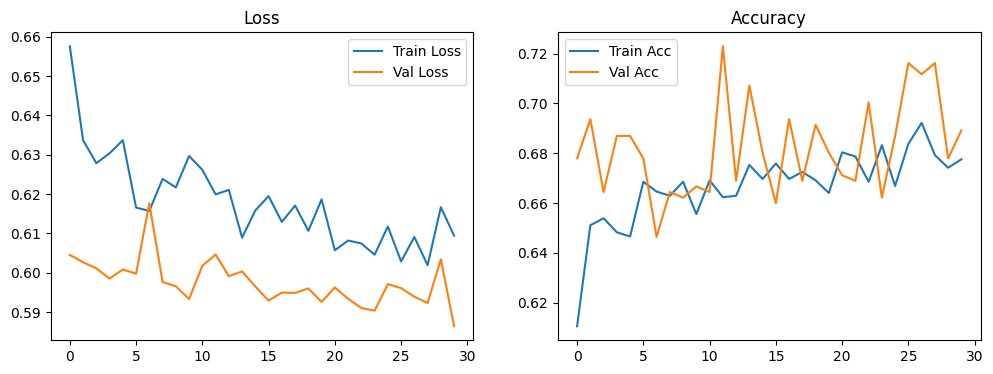

In [50]:
train_losses, val_losses, train_accs, val_accs = train_model(
    model_v3, train_loader, val_loader, criterion, optimizer, n_epochs=30, device=device
)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [51]:
y_true, y_pred, y_proba = evaluate_model(model_v3, test_loader, device)

Testing: 100%|██████████| 18/18 [00:08<00:00,  2.17it/s]


               precision    recall  f1-score   support

      Хорошо       0.82      0.67      0.73       375
       Плохо       0.50      0.69      0.58       180

    accuracy                           0.67       555
   macro avg       0.66      0.68      0.66       555
weighted avg       0.71      0.67      0.68       555

Accuracy: 0.6739
F1 (плохо): 0.5781
ROC-AUC: 0.7532


## Новый подход

Изучив статьи по данной проблематике, попробуем использовать один из подходов и сравнить с нашим базовым решением. Вот статья: https://acnsci.org/journal/index.php/cte/article/view/554/600 . Подход из статьи масштабирует спектрограмму до квадрата 64×64. Это сильно сжимает частотное и временное разрешение, но унифицирует вход и позволяет использовать фиксированные полносвязные слои без адаптивного пулинга. Модель начинается с 32 фильтров, затем 64 и 64.

In [91]:
class MelSpectrogramDatasetV2(Dataset):
    def __init__(self, df, target_size=(64, 64)):
        self.df = df.reset_index(drop=True)
        self.target_size = target_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        spec = get_mel_spectrogram(row['path'])
        spec = spec.unsqueeze(0).unsqueeze(0)
        spec = F.interpolate(spec, size=self.target_size, mode='bilinear', align_corners=False)
        spec = spec.squeeze(0)
        label = torch.tensor(row['label'], dtype=torch.long)
        return spec, label

In [92]:
train_datasetV2 = MelSpectrogramDatasetV2(df_train)
val_datasetV2 = MelSpectrogramDatasetV2(df_val)
test_datasetV2 = MelSpectrogramDatasetV2(df_test)

In [93]:
batch_size = 32
train_loaderV2 = DataLoader(train_datasetV2, batch_size=batch_size, shuffle=True, num_workers=2)
val_loaderV2 = DataLoader(val_datasetV2, batch_size=batch_size, shuffle=False, num_workers=2)
test_loaderV2 = DataLoader(test_datasetV2, batch_size=batch_size, shuffle=False, num_workers=2)

In [94]:
class NewAudioCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(2, 2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.AvgPool2d(2, 2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.AvgPool2d(2, 2)
        )
        self.flatten = nn.Flatten()
        self.dropout1 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 8 * 8, 64)
        self.relu = nn.ReLU()
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.flatten(x)
        x = self.dropout1(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

In [95]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_article = NewAudioCNN(num_classes=2).to(device)

weight_1 = len(df_train[df_train['label']==0]) / len(df_train[df_train['label']==1])
class_weights = torch.tensor([1.0, weight_1]).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model_article.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

In [88]:
train_losses, val_losses, train_accs, val_accs = train_model(
    model_article, train_loaderV2, val_loaderV2, criterion, optimizer, n_epochs=30, device=device
)

Val Epoch 1: 100%|██████████| 14/14 [00:06<00:00,  2.01it/s]


Epoch 1:         
 Train Loss: 0.6924, Acc: 0.5699         
 Val Loss: 0.6242, Acc: 0.6712


Val Epoch 2: 100%|██████████| 14/14 [00:05<00:00,  2.52it/s]


Epoch 2:         
 Train Loss: 0.6449, Acc: 0.6297         
 Val Loss: 0.6138, Acc: 0.6554


Val Epoch 3: 100%|██████████| 14/14 [00:05<00:00,  2.47it/s]


...

Epoch 28:         
 Train Loss: 0.4115, Acc: 0.7875         
 Val Loss: 0.9340, Acc: 0.7275


Val Epoch 29: 100%|██████████| 14/14 [00:05<00:00,  2.50it/s]


Epoch 29:         
 Train Loss: 0.4200, Acc: 0.8005         
 Val Loss: 0.8016, Acc: 0.7050


Val Epoch 30: 100%|██████████| 14/14 [00:06<00:00,  2.04it/s]

Epoch 30:         
 Train Loss: 0.3790, Acc: 0.8083         
 Val Loss: 0.8588, Acc: 0.7027


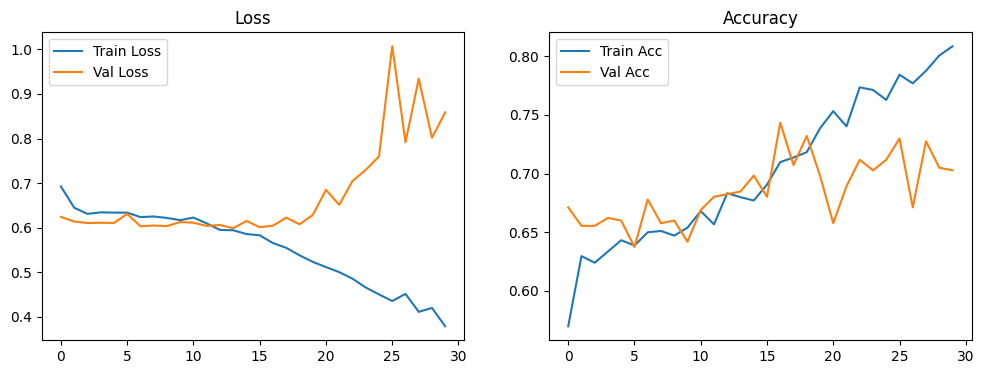

In [89]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [90]:
y_true, y_pred, y_proba = evaluate_model(model_article, test_loaderV2, device)

Testing: 100%|██████████| 18/18 [00:08<00:00,  2.11it/s]


               precision    recall  f1-score   support

      Хорошо       0.82      0.72      0.77       375
       Плохо       0.54      0.68      0.60       180

    accuracy                           0.70       555
   macro avg       0.68      0.70      0.68       555
weighted avg       0.73      0.70      0.71       555

Accuracy: 0.7045
F1 (плохо): 0.5980
ROC-AUC: 0.7303


По графику видно, что ближе к 20 эпохе появляется переобучение. Loss валидации начинает сильно опережать Loss обучения. Кроме того, метрики получились хуже, чем у лучшей ML-модели и базовой DL-модели.

## Вывод

## Результаты экспериментов с CNN

| Модель | Архитектура | Веса классов | Accuracy | F1 (плохо) | ROC-AUC |
|--------|-------------|--------------|----------|------------|---------|
| **Базовая CNN** (AudioCNN) | 3 свёрточных блока (8 - 16 - 32), MaxPool, BatchNorm, AdaptiveAvgPool, Dropout(0.5) | [1, 2.09] | 0.7297 | 0.6324 | 0.7789 |
| Базовая CNN с усилением весов | 3 свёрточных блока (8 - 16 - 32), MaxPool, BatchNorm, AdaptiveAvgPool, Dropout(0.5) | [1, 2.5] | 0.5982 | 0.5736 | 0.7732 |
| Упрощённая CNN (AudioCNNv3) | Dropout(0.7) и выходной Dropout(0.5) | [1, 2.0] | 0.6739 | 0.5781 | 0.7532 |
| Модель из статьи (NewAudioCNN) | 3 свёрточных слоя (32-64-64), AvgPool, без BatchNorm, вход 64×64 | [1, 2.09] | 0.7045 | 0.5980 | 0.7303 |

- Лучшая CNN — базовая архитектура с весами, обратно пропорциональными частоте классов ([1, 2.09]). Она достигла F1 = 0.632 и ROC-AUC = 0.779, что сопоставимо с лучшей ML‑моделью.

- Увеличение веса редкого класса до 2.5 привело к резкому падению accuracy (с 0.73 до 0.60), хотя recall по «плохому» классу вырос, но точность упала - модель стала слишком часто предсказывать дефект.

- Упрощение модели (больший dropout, меньшие веса) не улучшило результаты - F1 снизился до 0.578.

- Модель из статьи (с AveragePooling и масштабированием спектрограммы до 64×64) показала результаты хуже базовой CNN (F1 = 0.598, ROC-AUC = 0.730).